In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For building the model and evaluating it
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # get Linear regression model
from sklearn import metrics    # get RSS , MSE , RMSE , MAE and R2

# Set a style for our plots
sns.set_style('whitegrid')

In [7]:
df = pd.read_csv("advertising.csv")
print(df.head())

print(df.isnull().sum())

print(df.describe())
df.info()


print(df.duplicated().sum())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio   


 Pairplot of the dataset:


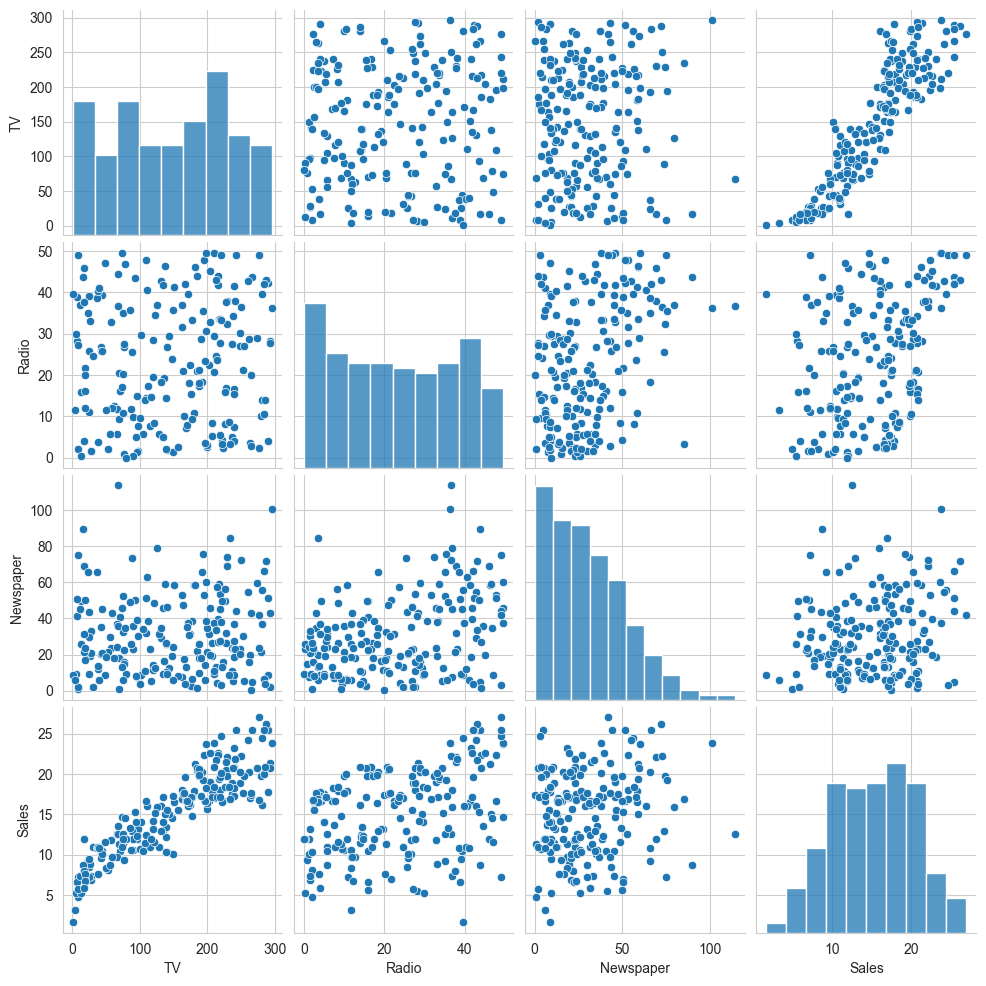

In [8]:
print("\n Pairplot of the dataset:")
sns.pairplot(df)
plt.show()

 Define Feature and Target column using X and Y 

In [20]:
X = df[["TV"]]
print(X.shape)
# X = df["TV"]
# print(X.shape)
y = df["Sales"]

print(np.ndim(X))

(200, 1)
2


Split dataset for train and test data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)  # Reproduce the same results using random_state

print("Training set shape (X_train) : ",X_train.shape)
print("Test set shape (X_test) : ",X_test.shape)

Training set shape (X_train) :  (160, 1)
Test set shape (X_test) :  (40, 1)


Train a model

In [11]:
simple_model = LinearRegression()   

simple_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print(f'b: {simple_model.intercept_:.4f}')
print(f'w: {simple_model.coef_[0]:.4f}')

b: 7.0071
w: 0.0555


In [13]:
print(simple_model.intercept_.dtype)

float64


In [14]:
print(simple_model.coef_.dtype)

float64


Get RMSE

In [15]:
y_train_predict = simple_model.predict(X_train)
y_test_predict = simple_model.predict(X_test)

rmse_train = metrics.root_mean_squared_error(y_train, y_train_predict)
rmse_test = metrics.root_mean_squared_error(y_test, y_test_predict)

print(f'Train RMSE: {rmse_train}')
print(f'Test RMSE: {rmse_test}')

Train RMSE: 2.235719650683013
Test RMSE: 2.470035001123256


In [16]:
mae_train = metrics.mean_absolute_error(y_train, y_train_predict)
mae_test = metrics.mean_absolute_error(y_test, y_test_predict)

print(f'Train MAE: {mae_train}')
print(f'Test MAE: {mae_test}')

Train MAE: 1.8005092256620792
Test MAE: 1.9502948931650088


In [17]:
r_train = metrics.r2_score(y_train,y_train_predict)
r_test = metrics.r2_score(y_test,y_test_predict)

print(f'Train R2: {r_train}')
print(f'Test R2: {r_test}')


Train R2: 0.8134866044709264
Test R2: 0.802561303423698


Inference

In [18]:
new_TV = pd.DataFrame({"TV":[200.0]})
pred_sales = simple_model.predict(new_TV)
print(f"Predicted Sales: {pred_sales[0]:.4f}")


Predicted Sales: 18.1037
